# UAV Dataset Analysis & Preprocessing (for Report)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from kaggle.ML_HW2.code.dataset import get_datasets
from torchvision import transforms as T
from PIL import Image
import torch
import json
import matplotlib.pyplot as plt

/homes/nfs/ben/project/AI-pruning-project/kaggle/dataset.py:65: SyntaxWarning: invalid escape sequence '\d'
  int(text) if text.isdigit() else text.lower() for text in re.split("(\d+)", s)


# 1. Dataset Structure Overview

In [2]:
train_ds, test_ds = get_datasets("data")

print(f"Train images: {len(train_ds)}")
print(f"Test images:  {len(test_ds)}")
print("Each mask has 16 semantic classes (0–15).")
unique_labels = set()

for i in range(50):  # 若要完整統計可改 len(train_ds)
    _, mask = train_ds[i]
    unique_labels.update(np.unique(mask.numpy()))

print(f"Unique classes found in first 50 masks: {sorted(list(unique_labels))}")
print(f"Total unique classes detected: {len(unique_labels)}")

if len(unique_labels) == 16:
    print("✅ Confirmed: All 16 semantic classes (0–15) are present in the dataset.")
else:
    print("⚠️ Warning: Not all 16 classes appear in the sampled data.")

Train images: 4000
Test images:  1000
Each mask has 16 semantic classes (0–15).
Unique classes found in first 50 masks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Total unique classes detected: 16
✅ Confirmed: All 16 semantic classes (0–15) are present in the dataset.


# 2. Example Image + Mask Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..1.2979523].


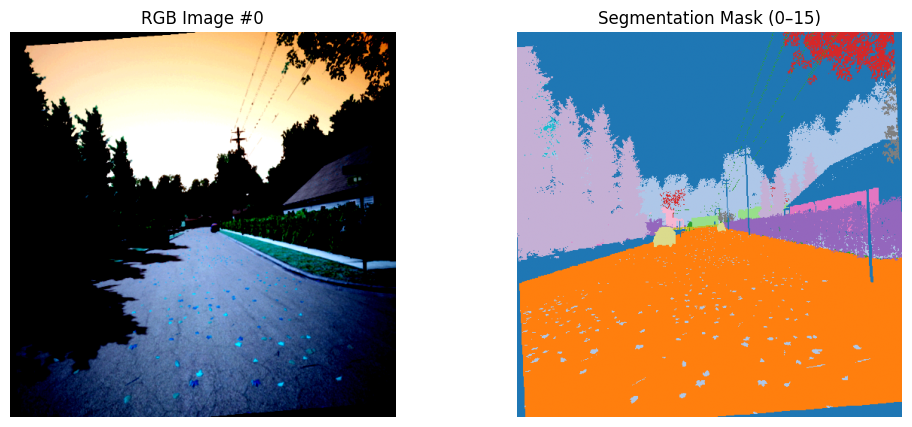

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.5005665].


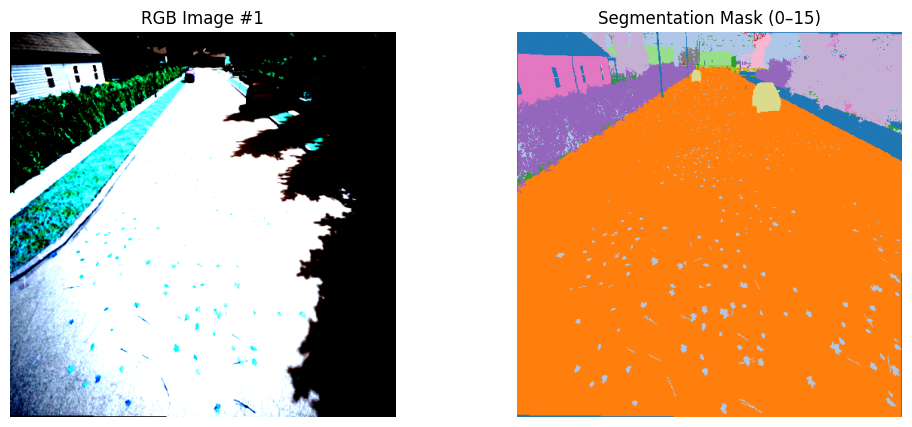

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.843908..1.367669].


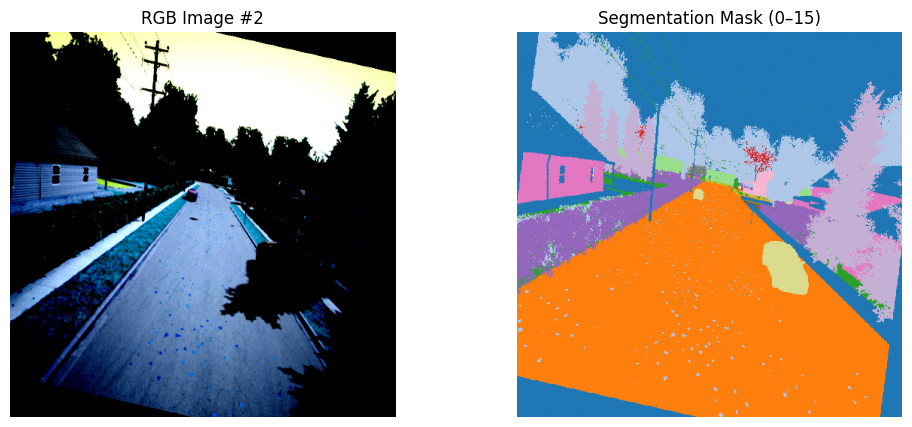

In [3]:
def show_samples(idx):
    img, mask = train_ds[idx]
    img_np = np.transpose(img.numpy(),(1,2,0))
    mask_np = mask.numpy()
    
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title(f"RGB Image #{idx}")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.imshow(mask_np, cmap="tab20", vmin=0, vmax=15)
    plt.title("Segmentation Mask (0–15)")
    plt.axis("off")
    plt.show()
    
for i in [0, 1, 2]:
    show_samples(i)
    

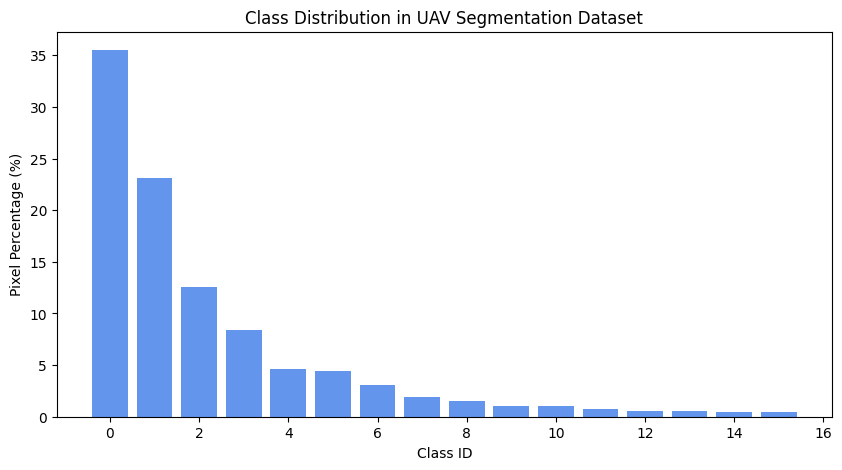

In [4]:
num_classes = 16
pixel_counts = np.zeros(num_classes, dtype=np.int64)

for i in range(len(train_ds)):
    _, mask = train_ds[i]
    mask_np = mask.numpy()
    for c in range(num_classes):
        pixel_counts[c] += np.sum(mask_np == c)

distribution = pixel_counts / np.sum(pixel_counts) * 100

plt.figure(figsize=(10, 5))
plt.bar(range(num_classes), distribution, color="cornflowerblue")
plt.xlabel("Class ID")
plt.ylabel("Pixel Percentage (%)")
plt.title("Class Distribution in UAV Segmentation Dataset")
plt.show()

# 3. training_log Directory Overview

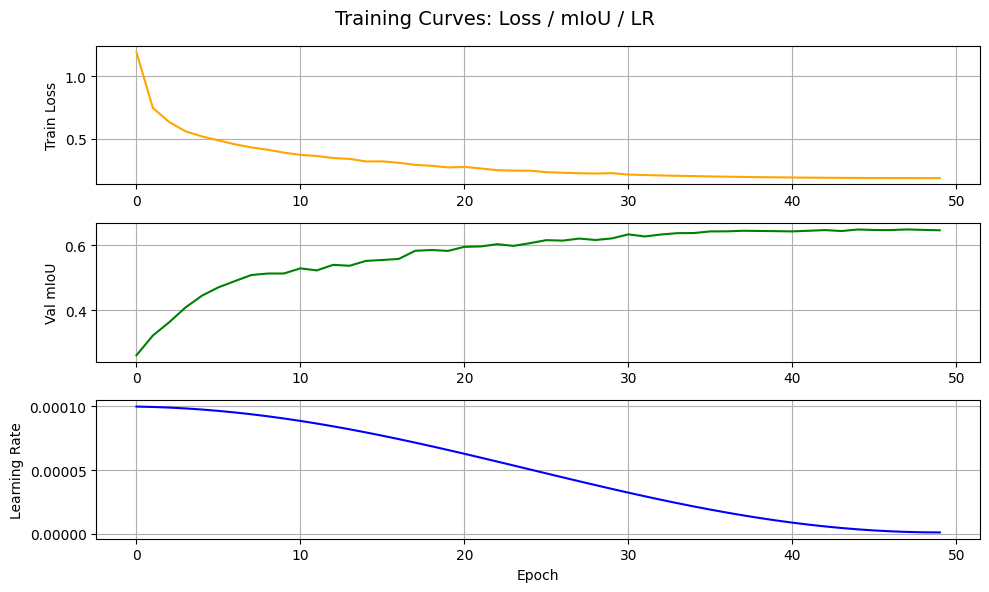

In [ ]:
with open("./checkpoints/training_log_unetpp.json", "r") as f:
    history = json.load(f)

train_loss = history["train_loss"]
val_miou = history["val_miou"]
lrs = history["lr"]

plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(train_loss, color="orange")
plt.ylabel("Train Loss")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(val_miou, color="green")
plt.ylabel("Val mIoU")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(lrs, color="blue")
plt.ylabel("Learning Rate")
plt.xlabel("Epoch")
plt.grid(True)

plt.suptitle("Training Curves: Loss / mIoU / LR", fontsize=14)
plt.tight_layout()
plt.show()

# 4. models Directory Overview

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2739873].


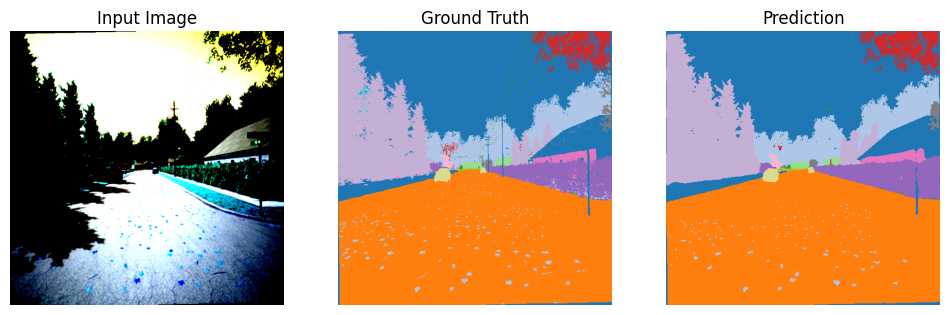

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].


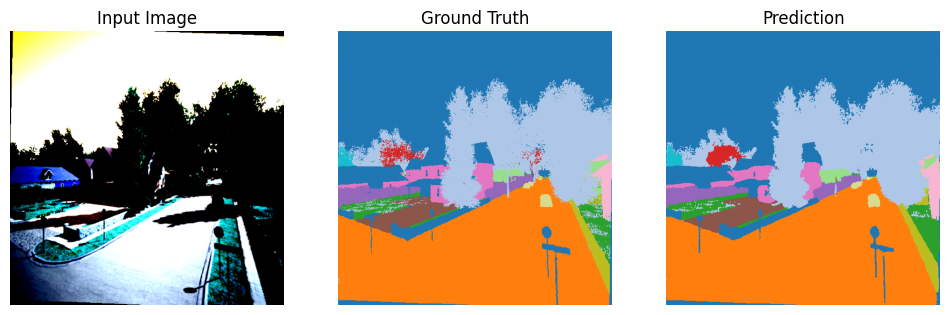

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4025275].


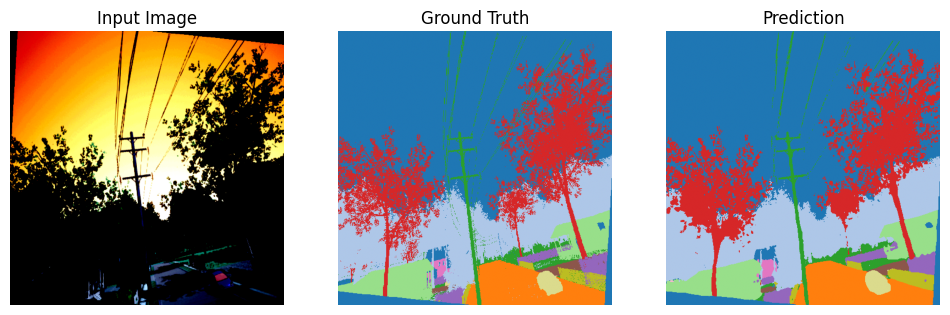

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from kaggle.ML_HW2.code.dataset import get_datasets
import segmentation_models_pytorch as smp

from torchvision.models.segmentation import deeplabv3_resnet101

# 載入資料與模型
train_ds, test_ds = get_datasets("./data")
# model = deeplabv3_resnet101(weights=None, num_classes=16)
# model.load_state_dict(
#     torch.load("./checkpoints/best_deeplabv3_r101.pth", map_location="cpu")
# )
model = smp.UnetPlusPlus(
    encoder_name="resnet101",  # backbone
    encoder_weights="imagenet",  # ImageNet pretrained
    in_channels=3,  # RGB
    classes=16,  # number of segmentation classes
)
model.load_state_dict(
    torch.load("./checkpoints/best_deeplabv3.pth", map_location="cuda")
)
model.eval()

# 選擇幾張驗證圖像觀察結果
for i in [0, 10, 20]:
    img, mask = train_ds[i]
    with torch.no_grad():
        out = model(img.unsqueeze(0))
        pred = torch.argmax(out.squeeze(), dim=0).cpu().numpy()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask.numpy(), cmap="tab20", vmin=0, vmax=15)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred, cmap="tab20", vmin=0, vmax=15)
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
import segmentation_models_pytorch as smp

from torchvision.models.segmentation import deeplabv3_resnet101
from kaggle.ML_HW2.code.dataset import get_datasets

# 載入最佳模型
# model = deeplabv3_resnet101(weights=None, num_classes=16)
# model.load_state_dict(
#     torch.load("./checkpoints/best_deeplabv3.pth", map_location="cuda")
# )
model = smp.UnetPlusPlus(
    encoder_name="resnet101",  # backbone
    encoder_weights="imagenet",  # ImageNet pretrained
    in_channels=3,  # RGB
    classes=16,  # number of segmentation classes
)
model.load_state_dict(
    torch.load("./checkpoints/best_deeplabv3.pth", map_location="cuda")
)
model.eval().cuda()

_, test_ds = get_datasets("./data")
test_img_dir = "./data/test/imgs"
save_dir = "./pred_masks_fixed"
os.makedirs(save_dir, exist_ok=True)

test_img_files = sorted(os.listdir(test_img_dir))

with torch.no_grad():
    for i, (img_tensor, fname) in enumerate(zip(test_ds, test_img_files)):
        # 如果 test_ds 只回傳影像 (無 mask)，這裡用 test_img_files 來對應名稱
        if fname.endswith(".png"):
            img = img_tensor.unsqueeze(0).cuda()
            out = model(img)
            pred = torch.argmax(out, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

            # 🔹 根據原圖的實際尺寸 resize
            orig_img = Image.open(os.path.join(test_img_dir, fname))
            w, h = orig_img.size  # 注意 PIL 是 (width, height)
            pred_resized = cv2.resize(pred, (w, h), interpolation=cv2.INTER_NEAREST)

            Image.fromarray(pred_resized).save(os.path.join(save_dir, fname))

print(f"✅ Saved corrected masks to {save_dir}")

✅ Saved corrected masks to ./pred_masks_fixed


In [10]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm


def rle_encode(mask):
    pixels = mask.flatten(order="F")
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[:-1:2]
    return " ".join(str(x) for x in runs)


mask_dir = "./pred_masks_fixed"
output_csv = "submission.csv"
num_classes = 16

records = []

for fname in tqdm(sorted(os.listdir(mask_dir)), desc="encoding masks"):
    if not fname.endswith(".png"):
        continue

    # 🔹 改這行：移除 mask_ 前綴
    img_id = fname.replace("mask_0", "4")

    mask = cv2.imread(os.path.join(mask_dir, fname), cv2.IMREAD_GRAYSCALE)
    row = {"img": img_id}
    for class_id in range(num_classes):
        class_mask = (mask == class_id).astype(np.uint8)
        if class_mask.sum() == 0:
            row[f"class_{class_id}"] = "none"
        else:
            row[f"class_{class_id}"] = rle_encode(class_mask)
    records.append(row)

df = pd.DataFrame(records)
df.to_csv(output_csv, index=False)
print(f"✅ Saved fixed submission file: {output_csv}")

encoding masks: 100%|██████████| 1000/1000 [00:15<00:00, 64.21it/s]


✅ Saved fixed submission file: submission.csv


In [11]:
import os
import datetime

COMPETITION = "2025-ncku-ee-ml-16-classes-segmentation"
FILE = "submission.csv"

# 自動生成當前時間戳記
timestamp = datetime.datetime.now().strftime("%m%d-%H%M")
message = f"AutoSubmit {timestamp} | Unet++ 512x512 + resnet101 | cosine LR | multi-loss tuned"

cmd = f'kaggle competitions submit -c {COMPETITION} -f {FILE} -m "{message}"'
print("🚀 Submitting with message:")
print(message)
os.system(cmd)

🚀 Submitting with message:
AutoSubmit 1018-1240 | Unet++ 512x512 + resnet101 | cosine LR | multi-loss tuned


100%|██████████| 122M/122M [00:05<00:00, 21.9MB/s] 


Successfully submitted to 2025 NCKU EE ML UAV Segmentation

0

In [12]:
img = np.array(Image.open("data/test/imgs/4000.png"))
pred = np.array(Image.open("pred_masks_fixed/4000.png"))
print(img.shape, pred.shape)

(600, 800, 3) (600, 800)


In [3]:
import numpy as np
import torch
from tqdm import tqdm

NUM_CLASSES = 16

img_per_class = np.zeros(NUM_CLASSES, dtype=np.int64)

for i in tqdm(range(len(train_ds)), desc="Scanning images"):
    _, mask = train_ds[i]
    if isinstance(mask, torch.Tensor):
        m = mask.long()
    else:
        m = torch.as_tensor(mask, dtype=torch.long)

    present = torch.unique(m)
    for c in present.cpu().numpy():
        if 0 <= c < NUM_CLASSES:
            img_per_class[c] += 1

print("Number of images per class:")
for c in range(NUM_CLASSES):
    print(f"class {c:2d}: {img_per_class[c]} images")

Scanning images: 100%|██████████| 4000/4000 [08:41<00:00,  7.67it/s]

Number of images per class:
class  0: 4000 images
class  1: 3999 images
class  2: 3325 images
class  3: 3975 images
class  4: 3459 images
class  5: 3285 images
class  6: 3572 images
class  7: 2382 images
class  8: 3176 images
class  9: 2529 images
class 10: 2011 images
class 11: 1939 images
class 12: 2831 images
class 13: 3043 images
class 14: 1399 images
class 15: 1782 images
